In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import smarts_cerebellum.globals as gl

In [2]:
cst = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_WM', 'summary_MNISymC_CST_WM_mod.tsv'), sep = '\t')
cst['hemisphere'] = cst.regionname.str[0].astype(str).str.upper()
cst = cst[cst.isPatient == 1] # just patients


regions = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R','M3R', 'M4R']
cerebel = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')
cerebel = cerebel[cerebel.isPatient==1] # just patients
cerebel = cerebel[cerebel.regionname.isin(regions)]
cerebel['hemisphere'] = cerebel.regionname.str[2]


behav = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', 'summary_paretic.dat'), sep = '\t') # only paretic hand
# behavioural data copied from smarts/bedside/analysis/

# make subj_id column consistent
behav['subj_id'] = behav['subj_name'].str.strip()
behav.loc[behav['week']==1, 'week'] = 0
behav.rename(columns = {'week': 'Week'}, inplace = True)


# NORMALISE AFFECTED VOLUME BY UNAFFECTED VOLUME - CST (affected = ipsi i.e. right)
cst['regionname_bilat'] = cst.regionname.str[-3:]
left_cst = cst[cst.hemisphere == 'L'][['subj_id', 'Week', 'region', 'regionname', 'regionname_bilat', 'mean']].rename(columns = {'mean': 'left_mean'})
right_cst = cst[cst.hemisphere == 'R'][['subj_id', 'Week', 'region', 'regionname', 'regionname_bilat', 'mean']].rename(columns = {'mean': 'right_mean'})
norm_cst = left_cst.merge(right_cst, on = ['subj_id', 'Week', 'regionname_bilat'], suffixes = ('_left', '_right'))

# normalise contralesional (affected) side by unaffected side; analogous to Jing's behav norm
norm_cst['right_norm'] = norm_cst['right_mean']/norm_cst['left_mean']



# NORMALISE AFFECTED VOLUME BY UNAFFECTED VOLUME - CEREBELLUM (affected - contra i.e. left)
cerebel['regionname_bilat'] = cerebel.regionname.str[:2]
left_cerebel = cerebel[cerebel.hemisphere == 'L'][['subj_id', 'Week', 'region', 'regionname', 'regionname_bilat', 'mean']].rename(columns = {'mean': 'left_mean'})
right_cerebel = cerebel[cerebel.hemisphere == 'R'][['subj_id', 'Week', 'region', 'regionname', 'regionname_bilat', 'mean']].rename(columns = {'mean': 'right_mean'})
norm_cerebel = left_cerebel.merge(right_cerebel, on = ['subj_id', 'Week', 'regionname_bilat'], suffixes = ('_left', '_right'))

norm_cerebel['left_norm'] = norm_cerebel['left_mean']/norm_cerebel['right_mean']

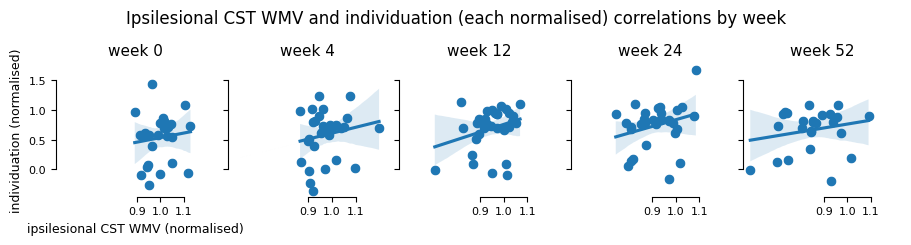

In [3]:
# affected: ipsilesional CST, paretic hand
weeks = [0, 4, 12, 24, 52]

fig, axs = plt.subplots(1, 5, figsize = (9,2), sharex = True, sharey = True, constrained_layout = True)
for i, week in enumerate(weeks):
    behav_plot = behav[behav.Week == week]
    #ipsi_cst = cst[(cst.hemisphere == 'R') & (cst.Week == week)] # all lesions (mirrored to) right hemisphere
    ipsi_cst = norm_cst[(norm_cst.Week == week)] # all lesions (mirrored to) right hemisphere
    aff_df = pd.merge(ipsi_cst, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_cst', '_behav'))

    ax = axs[i]
    sns.scatterplot(x = 'right_norm', y = 'indiv_norm', data =aff_df, ax = ax, edgecolor = None,  legend = False)
    sns.regplot(x = 'right_norm', y = 'indiv_norm', data = aff_df, ax = ax)
    sns.despine(trim = True)

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (normalised)")
axs[0].set_xlabel("ipsilesional CST WMV (normalised)")

fig.suptitle(f"Ipsilesional CST WMV and individuation (each normalised) correlations by week", y = 1.15)
plt.show()


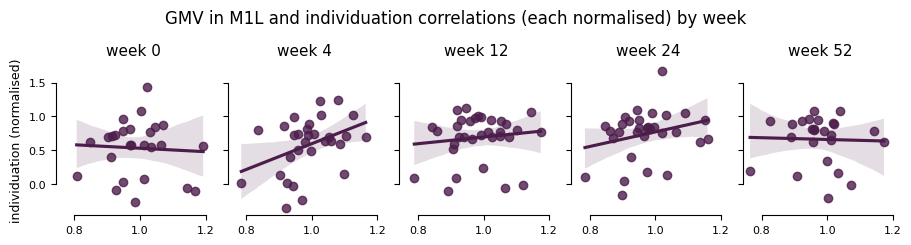

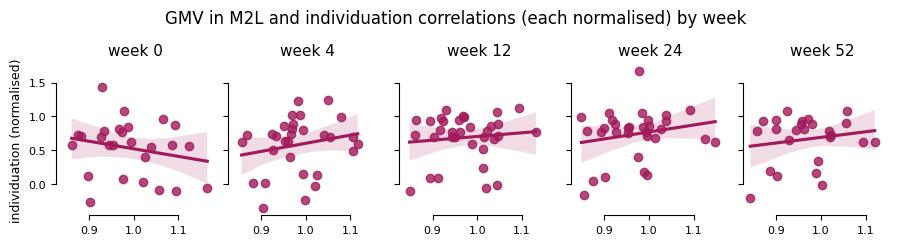

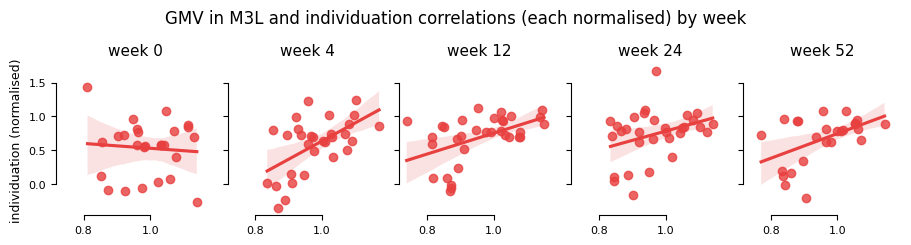

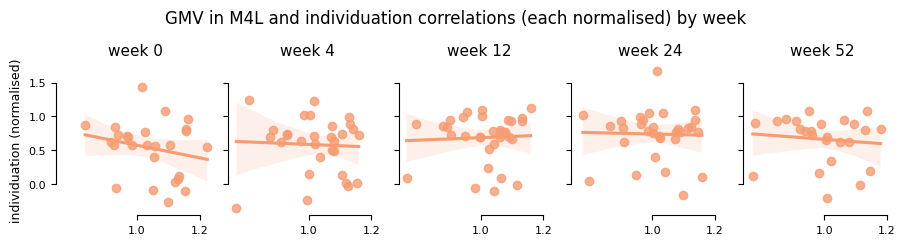

In [8]:
# affected: contralesional cerebellum, paretic hand
weeks = [0, 4, 12, 24, 52]
colors = sns.color_palette('rocket', n_colors = 4)

for r, region in enumerate(regions[:4]): # left ROIs
    fig, axs = plt.subplots(1, 5, figsize = (9,2), sharex = True, sharey = True, constrained_layout = True)
    for i, week in enumerate(weeks):
        behav_plot = behav[behav.Week == week]
        contra_cerebel = norm_cerebel[(norm_cerebel.Week == week)]# & (cerebel.regionname == cerebellar_region)]
        #contra_cerebel = cerebel[(cerebel.hemisphere == 'L') & (cerebel.Week == week)]# & (cerebel.regionname == cerebellar_region)] # all lesions (mirrored to) right hemisphere
        aff_df = pd.merge(contra_cerebel, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_cerebel', '_behav'))

        ax = axs[i]
        #sns.scatterplot(x = 'left_norm', y = 'indiv_norm', data = aff_df[aff_df.regionname == region], ax = ax, edgecolor = None, legend = False, alpha = .5, color = colors[r])
        sns.regplot(x = 'left_norm', y = 'indiv_norm', data = aff_df[aff_df.regionname_left == region], ax = ax, color = colors[r])
        sns.despine(trim = True)

        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.set_title(f'week {week}')
    axs[0].set_ylabel("individuation (normalised)")
    fig.suptitle(f'GMV in {region} and individuation correlations (each normalised) by week', y = 1.15)
    plt.show()
    #axs[0].set_xlabel(f"{region} GMV")

#fig.suptitle(f"Contralesional cerebellar GMV and individuation correlations by week", y = 1.15)


# Jing's plots
Strength and individuation correlation plots (Xu et al., 2017)

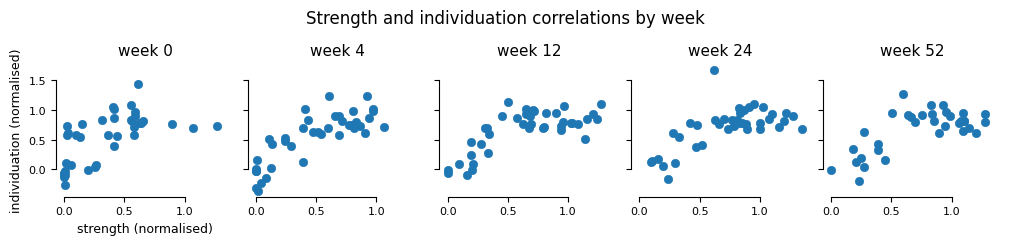

In [5]:
weeks = [0, 4, 12, 24, 52]

fig, axs = plt.subplots(1, 5, figsize = (10,2), sharex = True, sharey = True, constrained_layout = True)
for i, week in enumerate(weeks):
    ax = axs[i]
    sns.scatterplot(x = 'mvc_norm', y = 'indiv_norm', data = behav[behav.Week == week], ax = ax, edgecolor = None)
    sns.despine(trim = True)

    ax.set_ylabel('')
    ax.set_xlabel('')
    #ax.set_xticks([])
    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (normalised)")
axs[0].set_xlabel("strength (normalised)")

fig.suptitle("Strength and individuation correlations by week", y = 1.15)
plt.show()


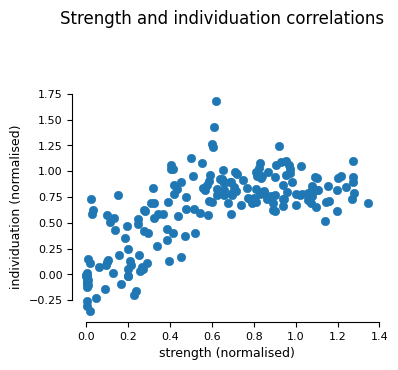

In [6]:
fig, ax = plt.subplots(figsize = (4,3))

sns.scatterplot(x = 'mvc_norm', y = 'indiv_norm', data = behav, edgecolor = None, ax = ax)
sns.despine(trim = True)


ax.set_ylabel("individuation (normalised)")
ax.set_xlabel("strength (normalised)")

fig.suptitle("Strength and individuation correlations", y = 1.15)
plt.show()
